# Machine Learning Lab – Logistic Regression Exercise 2

## Disease Susceptibility Prediction using Logistic Regression

### Objective
To build a Logistic Regression model to investigate whether a person is susceptible to a certain disease or not using the given medical dataset.

### Algorithm Used
Logistic Regression

### Problem Type
Supervised Learning – Classification

### Target Variable
Disease Susceptibility (Yes / No)

### Input Features
The medical attributes provided in the given dataset.

### Steps
1. Load the required libraries.
2. Load the given medical dataset.
3. Explore the dataset.
4. Check for missing values.
5. Prepare the input features and target variable.
6. Encode categorical variables if required.
7. Split the data into training and testing sets.
8. Train the Logistic Regression model.
9. Make predictions on the test data.
10. Evaluate the model using classification metrics.
11. Visualize the confusion matrix.
12. Summarize the results.

## Dataset

### Dataset Name
Medical Disease Susceptibility Dataset

### Dataset Description
The dataset contains medical attributes of individuals that can be used to investigate whether a person is susceptible to a certain disease.

### Input Features
The medical attributes provided in the dataset.

### Target Variable
Disease Susceptibility

### Target Encoding
- 1 → Susceptible
- 0 → Not Susceptible

### Data Preparation
The dataset will be inspected for missing values and categorical variables will be encoded into numerical form if required before training the Logistic Regression model.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the Pima Indians Diabetes dataset

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

col_names = [
    "pregnant",
    "glucose",
    "bp",
    "skin",
    "insulin",
    "bmi",
    "pedigree",
    "age",
    "label"
]

data = pd.read_csv(url, header=None, names=col_names)

print("Dataset loaded successfully!")
print("Shape of dataset:", data.shape)

data.head()

Dataset loaded successfully!
Shape of dataset: (768, 9)


,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# Explore the dataset

print("Dataset Information:")
data.info()

print("\nStatistical Summary:")
data.describe()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pregnant  768 non-null    int64  
 1   glucose   768 non-null    int64  
 2   bp        768 non-null    int64  
 3   skin      768 non-null    int64  
 4   insulin   768 non-null    int64  
 5   bmi       768 non-null    float64
 6   pedigree  768 non-null    float64
 7   age       768 non-null    int64  
 8   label     768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Statistical Summary:


,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [4]:
# Check for missing values

print("Missing values in each column:")
print(data.isnull().sum())

Missing values in each column:
pregnant    0
glucose     0
bp          0
skin        0
insulin     0
bmi         0
pedigree    0
age         0
label       0
dtype: int64


In [5]:
# Select input features and target variable

feature_cols = [
    'pregnant',
    'insulin',
    'bmi',
    'age',
    'glucose',
    'bp',
    'pedigree'
]

X = data[feature_cols]
y = data['label']

print("Selected features:")
print(feature_cols)

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Selected features:
['pregnant', 'insulin', 'bmi', 'age', 'glucose', 'bp', 'pedigree']

Feature shape: (768, 7)
Target shape: (768,)


In [6]:
# Check the distribution of the target variable

print("Target class distribution:")
print(y.value_counts())

print("\nTarget class percentages:")
print(y.value_counts(normalize=True) * 100)

Target class distribution:
label
0    500
1    268
Name: count, dtype: int64

Target class percentages:
label
0    65.104167
1    34.895833
Name: proportion, dtype: float64


In [7]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (614, 7)
Testing feature shape: (154, 7)
Training target shape: (614,)
Testing target shape: (154,)


In [8]:
# Train the Logistic Regression model

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [9]:
# Make predictions on the test data

y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print("First 20 predictions:")
print(y_pred[:20])

Predictions generated successfully!
First 20 predictions:
[1 0 0 0 0 0 0 1 0 1 0 1 0 0 0 0 1 0 1 0]


In [10]:
# Evaluate the Logistic Regression model

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Model Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(report)

Model Accuracy: 0.7207792207792207

Confusion Matrix:
[[83 17]
 [26 28]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.83      0.79       100
           1       0.62      0.52      0.57        54

    accuracy                           0.72       154
   macro avg       0.69      0.67      0.68       154
weighted avg       0.71      0.72      0.71       154



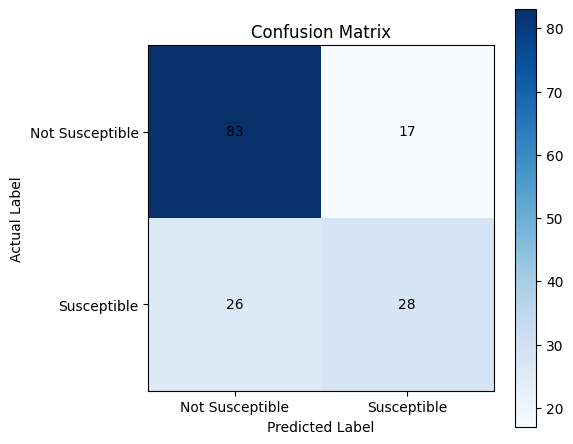

In [11]:
# Visualize the confusion matrix

plt.figure(figsize=(6, 5))

plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks([0, 1], ["Not Susceptible", "Susceptible"])
plt.yticks([0, 1], ["Not Susceptible", "Susceptible"])

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center")

plt.tight_layout()
plt.show()

In [12]:
# Calculate ROC-AUC score

y_prob = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.822962962962963


## Result Summary

The Logistic Regression model was trained to classify whether a person is susceptible to diabetes based on the given medical attributes.

### Performance Results

| Metric | Value |
|---|---:|
| Accuracy | 72.08% |
| ROC-AUC | 0.823 |
| Test Samples | 154 |

### Confusion Matrix

The confusion matrix contains:

- True Negatives (TN): 83
- False Positives (FP): 17
- False Negatives (FN): 26
- True Positives (TP): 28

## Conclusion

The Logistic Regression model was successfully implemented to predict diabetes susceptibility using the given medical dataset. The model achieved an accuracy of 72.08% and a ROC-AUC score of 0.823 on the test dataset.

The confusion matrix and classification report were used to evaluate the model's performance. The results show that the model can distinguish between the two classes, although some susceptible cases were incorrectly classified as not susceptible.

Thus, the experiment demonstrates the application of Logistic Regression for binary disease susceptibility classification.